In [1]:
import numpy as np
import pyoti.sparse as oti
from jetgp.full_degp.degp import degp
import jetgp.utils as utils
import time
from matplotlib import pyplot as plt
from scipy.stats import qmc
from typing import List, Dict, Callable

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_bases = 4
n_order = 2
num_training_pts = 25
slice_grid_resolution = 25
lower_bounds = [-5.0]*4
upper_bounds = [5.0]*4
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 200
random_seed = 1354
np.random.seed(random_seed)

In [3]:
def styblinski_tang_4d(X, alg=oti):
    """
    Styblinski–Tang function in 4D:
    f(x1,x2,x3,x4) = 0.5 * sum_{i=1}^4 (x_i^4 - 16 x_i^2 + 5 x_i)
    """
    x1, x2, x3, x4 = X[:,0], X[:,1], X[:,2], X[:,3]
    return 0.5 * (x1**4 - 16*x1**2 + 5*x1 +
                  x2**4 - 16*x2**2 + 5*x2 +
                  x3**4 - 16*x3**2 + 5*x3 +
                  x4**4 - 16*x4**2 + 5*x4)

In [4]:
def analyze_derivatives(n_bases, n_order):
    """Select main derivatives only (1st and 2nd order) and print counts."""
    complete_indices = utils.gen_OTI_indices(n_bases, n_order)
    complete_count = sum(len(group) for group in complete_indices)

    der_indices = [
        [[[i + 1, 1]] for i in range(n_bases)],  # 1st order
        [[[i + 1, 2]] for i in range(n_bases)]   # 2nd order
    ]
    selective_count = sum(len(group) for group in der_indices)

    print(f"Complete derivative set: {complete_count} terms (incl. cross-terms)")
    print(f"Selective strategy: {selective_count} terms (main derivatives only)")
    print(f"Reduction factor: {complete_count/selective_count:.1f}x")
    return der_indices

In [5]:
def generate_training_data(n_bases, n_order, num_training_pts, lower_bounds, upper_bounds, der_indices):
    sampler = qmc.Sobol(d=n_bases, scramble=True, seed=42)
    sobol_sample = sampler.random_base2(m=int(np.ceil(np.log2(num_training_pts))))
    X_train = utils.scale_samples(sobol_sample, lower_bounds, upper_bounds)

    X_train_pert = oti.array(X_train)
    for i in range(n_bases):
        X_train_pert[:, i] += oti.e(i+1, order=n_order)

    y_train_hc = styblinski_tang_4d(X_train_pert)
    y_train_list = [y_train_hc.real]
    for group in der_indices:
        for sub_group in group:
            y_train_list.append(y_train_hc.get_deriv(sub_group))

    # Build derivative_locations: one entry per derivative, all at all points
    derivative_locations = []
    for i in range(len(der_indices)):
        for j in range(len(der_indices[i])):
            derivative_locations.append([k for k in range(len(X_train))])

    print(f"Total observations: {sum(d.shape[0] for d in y_train_list)}")
    print(f"Derivative locations: {len(derivative_locations)} entries, each with {len(X_train)} points")
    return X_train, y_train_list, derivative_locations

In [6]:
def train_model(X_train, y_train_list, n_order, n_bases, der_indices, derivative_locations, normalize_data, kernel, kernel_type, n_restarts, swarm_size):
    gp_model = degp(
        X_train, y_train_list, n_order, n_bases,
        der_indices,
        derivative_locations=derivative_locations,
        normalize=normalize_data,
        kernel=kernel, kernel_type=kernel_type
    )
    params = gp_model.optimize_hyperparameters(
        optimizer='pso',
        pop_size=250,
        n_generations=30,
        local_opt_every=30,
        debug=True
    )
    return gp_model, params

In [7]:
def evaluate_slice(X_test_fixed_values):
    x_lin = np.linspace(lower_bounds[0], upper_bounds[0], slice_grid_resolution)
    y_lin = np.linspace(lower_bounds[1], upper_bounds[1], slice_grid_resolution)
    X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)

    X_test = np.zeros((X1_grid.size, n_bases))
    X_test[:,0] = X1_grid.ravel()
    X_test[:,1] = X2_grid.ravel()
    for i, val in enumerate(X_test_fixed_values):
        X_test[:, i+2] = val

    y_pred, y_var = gp_model.predict(X_test, params, calc_cov=True)
    y_true = styblinski_tang_4d(X_test, alg=np)

    return {
        "X1_grid": X1_grid, "X2_grid": X2_grid,
        "y_true": y_true.reshape(X1_grid.shape),
        "y_pred": y_pred.reshape(X1_grid.shape),
        "nrmse": utils.nrmse(y_true, y_pred)
    }

In [8]:
def plot_slices(X_train, slice_results, slice_name="zero_slice"):
    fig, axes = plt.subplots(1,3, figsize=(18,5), sharex=True, sharey=True)
    X_train_proj = X_train[:,:2]

    # True function
    axes[0].contourf(slice_results["X1_grid"], slice_results["X2_grid"], slice_results["y_true"], levels=50, cmap="viridis")
    axes[0].scatter(X_train_proj[:,0], X_train_proj[:,1], c="red", edgecolor="k", s=50, label="Training points")
    axes[0].set_title(f"True Function ({slice_name})")
    axes[0].legend()

    # GP prediction
    axes[1].contourf(slice_results["X1_grid"], slice_results["X2_grid"], slice_results["y_pred"], levels=50, cmap="viridis")
    axes[1].scatter(X_train_proj[:,0], X_train_proj[:,1], c="red", edgecolor="k", s=50)
    axes[1].set_title(f"GP Prediction ({slice_name})")

    # Absolute error
    error_grid = np.abs(slice_results["y_true"] - slice_results["y_pred"])
    axes[2].contourf(slice_results["X1_grid"], slice_results["X2_grid"], error_grid, levels=50, cmap="magma")
    axes[2].scatter(X_train_proj[:,0], X_train_proj[:,1], c="red", edgecolor="k", s=50)
    axes[2].set_title(f"Absolute Error ({slice_name})")

    for ax in axes:
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
    plt.tight_layout()
    plt.show()

Complete derivative set: 14 terms (incl. cross-terms)
Selective strategy: 8 terms (main derivatives only)
Reduction factor: 1.8x
Total observations: 288
Derivative locations: 8 entries, each with 32 points


New best for swarm at iteration 1: [ 0.02279516  0.09497524  0.20586795  0.13493861  0.69434126 -5.72591109] 874.2092347793057


Best after iteration 1: [ 0.02279516  0.09497524  0.20586795  0.13493861  0.69434126 -5.72591109] 874.2092347793057


Best after iteration 2: [ 0.02279516  0.09497524  0.20586795  0.13493861  0.69434126 -5.72591109] 874.2092347793057


New best for swarm at iteration 3: [-0.78718021 -1.12060992 -0.42553376 -0.92708697  3.9714838  -4.58824157] 621.6753586048937
Best after iteration 3: [-0.78718021 -1.12060992 -0.42553376 -0.92708697  3.9714838  -4.58824157] 621.6753586048937


...

Best after iteration 26: [-0.91922614 -0.94380459 -0.93450381 -0.92160133  3.77745838 -4.8785549 ] -69.63962279208596


Best after iteration 27: [-0.91922614 -0.94380459 -0.93450381 -0.92160133  3.77745838 -4.8785549 ] -69.63962279208596


New best for swarm at iteration 28: [-0.92141863 -0.94274298 -0.93289171 -0.92072218  3.77155469 -4.8859265 ] -70.19140378952335
Best after iteration 28: [-0.92141863 -0.94274298 -0.93289171 -0.92072218  3.77155469 -4.8859265 ] -70.19140378952335


Best after iteration 29: [-0.92141863 -0.94274298 -0.93289171 -0.92072218  3.77155469 -4.8859265 ] -70.19140378952335


Local optimization did not improve:
Best after iteration 30: [-0.92141863 -0.94274298 -0.93289171 -0.92072218  3.77155469 -4.8859265 ] -70.19140378952335
Stopping: maximum iterations reached --> 30


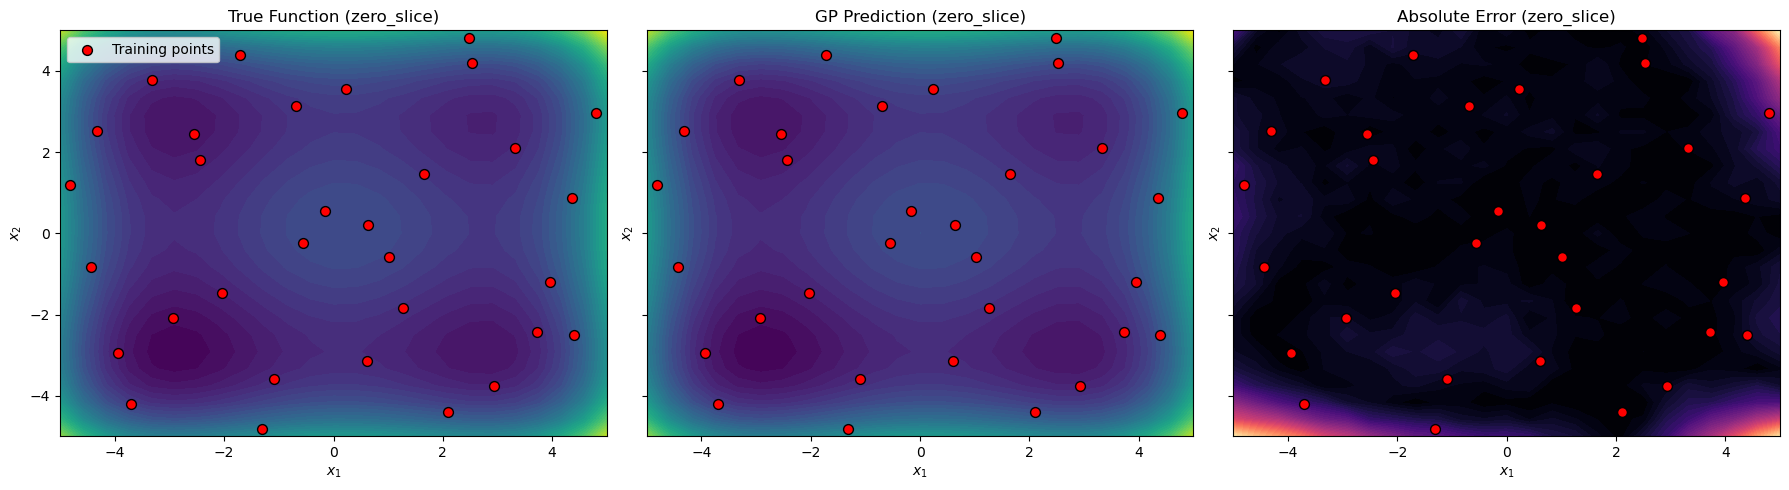

In [9]:
der_indices = analyze_derivatives(n_bases, n_order)
X_train, y_train_list, derivative_locations = generate_training_data(
    n_bases, n_order, num_training_pts,
    lower_bounds, upper_bounds, der_indices
)

gp_model, params = train_model(
    X_train, y_train_list, n_order, n_bases,
    der_indices, derivative_locations,
    normalize_data, kernel, kernel_type,
    n_restarts, swarm_size
)

# Evaluate a 2D slice with the last two dimensions fixed at zero
slice_results = evaluate_slice(X_test_fixed_values=[0.0, 0.0])

# Visualize the slice
plot_slices(X_train, slice_results, slice_name="zero_slice")